# Exploratory Data Analysis (EDA)

**EN**

This notebook conducts a focused exploratory analysis to assess whether behavioral social media indicators contain measurable and interpretable signal for early depression risk screening.

Only findings that directly inform modeling decisions are presented.


**JP**

本ノートブックでは、ソーシャルメディア利用に関する行動指標がうつ症状リスクの早期スクリーニングに対して測定可能かつ解釈可能なシグナルを有するかを評価するため、焦点を絞った探索的分析を行う。

モデル構築の意思決定に直接関係する結果のみを提示する。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "MS Gothic"

df = pd.read_csv("../data/raw/social_media_mental_health.csv", encoding="utf-8")

## 1. Data Overview & Sanity Check / データ概要と妥当性チェック

**EN**

Perform a compact structural sanity check to verify:
- dataset size
- missing value ratios
- duplicated rows
- basic numerical ranges
- categorical value distributions

This step ensures there are no obvious structural issues before proceeding to exploratory analysis.
We intentionally avoid extensive `info()` or `describe()` dumps to keep the notebook focused on decision-relevant insights.

**JP**

構造的な妥当性確認として、以下を簡潔にチェックする：
- データ規模（行数・列数）
- 欠損値の割合
- 重複行の有無
- 数値特徴量の基本的な範囲
- カテゴリ変数の分布

本ステップでは、明らかな構造的問題がないことを確認する。
意思決定に直接関係しないため、`info()` や `describe()` の大量出力は避け、必要最小限の確認に留める。

In [2]:
print("Shape:", df.shape)
df.head()

Shape: (8000, 15)


,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,U-b23639d2,18,Male,Hyper-Connected,Twitter/X,8.50,Gaming,Active,0,0,3.9,9,Mild,5,Mild
1,U-e7778765,20,Male,Digital Minimalist,TikTok,0.50,Gaming,Active,0,0,5.5,0,Minimal,8,Mild
2,U-76749892,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.9,1,Minimal,3,None-Minimal
3,U-dcbbd7f9,18,Female,Hyper-Connected,Snapchat,7.43,Gaming,Active,1,0,6.2,13,Moderate,0,None-Minimal
4,U-9e1ba278,18,Male,Hyper-Connected,LinkedIn,4.94,Entertainment/Comedy,Active,1,0,5.3,13,Moderate,10,Moderate


In [3]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
missing_pct

User_ID                      0.0
Age                          0.0
Gender                       0.0
User_Archetype               0.0
Primary_Platform             0.0
Daily_Screen_Time_Hours      0.0
Dominant_Content_Type        0.0
Activity_Type                0.0
Late_Night_Usage             0.0
Social_Comparison_Trigger    0.0
Sleep_Duration_Hours         0.0
GAD_7_Score                  0.0
GAD_7_Severity               0.0
PHQ_9_Score                  0.0
PHQ_9_Severity               0.0
dtype: float64

**EN**

No missing values observed in this dataset

**JP**

このデータセットでは欠損値は確認されなかった。

In [4]:
df.duplicated().sum()

0

In [5]:
df[['Sleep_Duration_Hours', 'Daily_Screen_Time_Hours']].describe()

,Sleep_Duration_Hours,Daily_Screen_Time_Hours
count,8000.000000,8000.000000
mean,5.803237,4.277210
std,1.344054,2.310486
min,3.000000,0.500000
25%,4.800000,2.420000
50%,5.800000,4.270000
75%,6.800000,6.050000
max,11.600000,11.310000


In [6]:
df['Late_Night_Usage'].value_counts(dropna=False, normalize=True)

Late_Night_Usage
0    0.620625
1    0.379375
Name: proportion, dtype: float64

In [7]:
df['User_Archetype'].value_counts(dropna=False, normalize=True)

User_Archetype
Hyper-Connected       0.258500
Digital Minimalist    0.253750
Average User          0.249125
Passive Scroller      0.238625
Name: proportion, dtype: float64

**EN**

All key behavioral variables fall within realistic value ranges.
Binary and categorical variables contain no unexpected labels.
No structural anomalies were detected at this stage.

**JP**

主要な行動特徴量はいずれも現実的な範囲に収まっている。
バイナリおよびカテゴリ変数にも想定外の値は確認されなかった。
本段階では、明らかな構造的異常は検出されていない。

## 2. Target Definition & Leakage Control / 目的変数とリーケージ対策

**EN**

Depression risk is defined as a binary indicator:

`PHQ-9 ≥ 10`  → `target = 1`  
`PHQ-9 < 10`  → `target = 0`

This setup is intended for **screening and prioritization** purposes, not clinical diagnosis.

Because the target is directly derived from PHQ-9 score, any PHQ-9 or GAD-7 scores 
and severity labels would introduce label leakage if used as features.

Therefore, these variables must be strictly excluded from the modeling feature set.

**JP**

うつ症状リスクは以下の2値分類として定義する：

`PHQ-9 ≥ 10`  → `target = 1`  
`PHQ-9 < 10`  → `target = 0`

本分析は医療診断を目的とするものではなく、
**スクリーニングおよび優先度付け**を想定している。

目的変数は PHQ-9 スコアから直接生成されるため、
PHQ-9 および GAD-7 のスコアや重症度ラベルを特徴量に含めると
ラベルリーケージが発生する。

そのため、これらの変数はモデル入力から厳密に除外する。

In [8]:
df = df.copy()
df["target"] = (df["PHQ_9_Score"] >= 10).astype(int)

LEAK_COLS = [
    "PHQ_9_Score",
    "PHQ_9_Severity",
    "GAD_7_Score",
    "GAD_7_Severity",
]
# 02_baseline.ipynb以降に解除される

## 3. Target Distribution & Metric Choice / 目的変数の分布と評価指標

**EN**

The target distribution shows moderate class imbalance:

`non-risk (0): 79.1%`  
`risk (1): 20.9%`

Although not extreme, this imbalance makes accuracy less informative,
as a naive majority classifier would already achieve ~79% accuracy.

Therefore, we focus on metrics that better reflect minority-class detection,
including PR-AUC and F1-score.

**JP**

目的変数の分布は以下の通りであり、中程度のクラス不均衡が確認される：

`non-risk (0): 79.1%`  
`risk (1): 20.9%`

極端ではないものの、この比率では多数派のみを予測する単純モデルでも
約79%のAccuracyが得られてしまう。

そのため、少数クラス（リスク群）の検出性能を適切に評価できる
PR-AUC や F1-score を重視する。

In [9]:
df["target"].value_counts(), df["target"].value_counts(normalize=True).round(3)

(target
 0    6326
 1    1674
 Name: count, dtype: int64,
 target
 0    0.791
 1    0.209
 Name: proportion, dtype: float64)

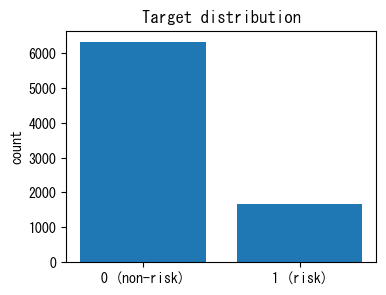

In [10]:
counts = df["target"].value_counts().sort_index()
plt.figure(figsize=(4,3))
plt.bar(["0 (non-risk)", "1 (risk)"], counts.values)
plt.title("Target distribution")
plt.ylabel("count")
plt.show()

## 4. Core Behavioral Signals / 主要な行動シグナル

**EN**

We examine a small set of behaviorally meaningful variables
that may serve as predictive correlates of risk:

- Sleep duration
- Daily screen time
- Late-night usage

The objective is to verify whether measurable distribution differences
between target groups are present prior to modeling.


**JP**

モデル化の前提として、リスクと関連し得る行動指標を限定的に検証する。

対象とする変数は以下の通り：

- 睡眠時間
- 1日のスクリーンタイム
- 深夜利用の有無

目的は、モデル化前にクラス間で測定可能な分布差が存在するかを確認することである。


In [11]:
df.groupby("target")["Sleep_Duration_Hours"].agg(["mean", "median"]).round(3)

,mean,median
target,,
0,6.018,6.1
1,4.993,5.0


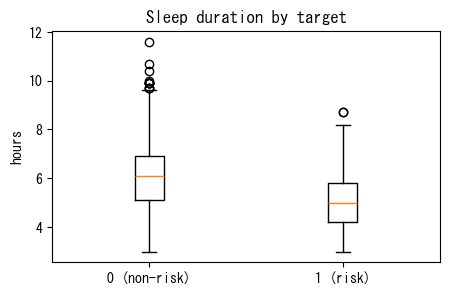

In [12]:
plt.figure(figsize=(5,3))
data0 = df.loc[df["target"]==0, "Sleep_Duration_Hours"]
data1 = df.loc[df["target"]==1, "Sleep_Duration_Hours"]
plt.boxplot([data0, data1], tick_labels=["0 (non-risk)", "1 (risk)"])
plt.title("Sleep duration by target")
plt.ylabel("hours")
plt.show()

**EN**

Sleep duration differs substantially between groups:

`non-risk mean: 6.02 hours`  
`risk mean: 4.99 hours`  

The ~1 hour gap is consistent across medians (6.1 vs 5.0)
and is clearly visible in the distribution plot.

This supports including sleep-related variables in a screening-oriented model.

**JP**

睡眠時間には明確な差が確認される：

`non-risk 平均：6.02 時間`  
`risk 平均：4.99 時間`  

中央値（6.1 vs 5.0）でも同様の傾向が見られ、
分布図上でも一貫した差が確認できる。

スクリーニング目的の特徴量として採用する妥当性が示唆される。

In [13]:
df.groupby("target")["Daily_Screen_Time_Hours"].agg(["mean", "median"]).round(3)

,mean,median
target,,
0,3.757,3.580
1,6.242,6.225


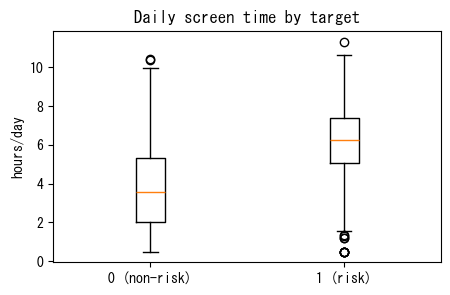

In [14]:
plt.figure(figsize=(5,3))
data0 = df.loc[df["target"]==0, "Daily_Screen_Time_Hours"]
data1 = df.loc[df["target"]==1, "Daily_Screen_Time_Hours"]
plt.boxplot([data0, data1], tick_labels=["0 (non-risk)", "1 (risk)"])
plt.title("Daily screen time by target")
plt.ylabel("hours/day")
plt.show()

**EN**

Daily screen time differs substantially between groups:

`non-risk mean: 3.76 hours/day`  
`risk mean: 6.24 hours/day`  

The ~2.5 hour increase represents a large behavioral gap,
clearly visible in the distribution plot.

This magnitude supports including screen time as a key predictive feature.


**JP**

1日のスクリーンタイムにも大きな差が確認される：

`non-risk 平均：3.76 時間`  
`risk 平均：6.24 時間`  

約2.5時間の差は行動的にも大きく、
分布図上でも明確に分離している。

予測特徴量として重要である可能性が高い。

In [15]:
ct = pd.crosstab(df["Late_Night_Usage"], df["target"], normalize="index")
ct.round(3)

target,0,1
Late_Night_Usage,,
0,0.961,0.039
1,0.513,0.487


In [16]:
p_risk_late1 = ct.loc[1, 1]
p_risk_late0 = ct.loc[0, 1]
print("P(target=1 | Late_Night_Usage=1):", round(float(p_risk_late1), 3))
print("P(target=1 | Late_Night_Usage=0):", round(float(p_risk_late0), 3))

P(target=1 | Late_Night_Usage=1): 0.487
P(target=1 | Late_Night_Usage=0): 0.039


**EN**

Late-night usage shows extremely strong separation:

`P(risk | late-night = 1) = 48.7%`  
`P(risk | late-night = 0) = 3.9%`  

This represents more than a 12× increase in conditional risk.

Such a large gap suggests that even a simple rule-based heuristic 
using late-night activity alone could achieve meaningful screening performance.


**JP**

深夜利用は非常に強い分離を示す：

`P(risk | late-night = 1) = 48.7%`  
`P(risk | late-night = 0) = 3.9%`  

条件付き確率は12倍以上の差があり、
極めて大きなギャップが確認される。

この結果は、深夜利用のみを用いた単純なルールベース手法でも
一定のスクリーニング性能が期待できることを示唆する。

## 5. Behavioral Archetypes / 行動アーキタイプによるセグメント

**EN**
We evaluate risk rate by `User_Archetype` as a compact behavioral segmentation.

Behavior-based segments can reveal structural differences in risk profilesthat may not be visible through simple aggregate analysis.

**JP**
`User_Archetype` ごとのリスク率を確認し、行動ベースのセグメントがどの程度リスク差を持つかを評価する。

行動セグメントは、単純な集計では見えにくい構造的なリスク差を可視化する可能性がある。

In [17]:
archetype_rate = df.groupby("User_Archetype")["target"].mean().sort_values(ascending=False)
(archetype_rate * 100).round(1)

User_Archetype
Hyper-Connected       43.2
Passive Scroller      26.8
Average User          11.9
Digital Minimalist     1.5
Name: target, dtype: float64

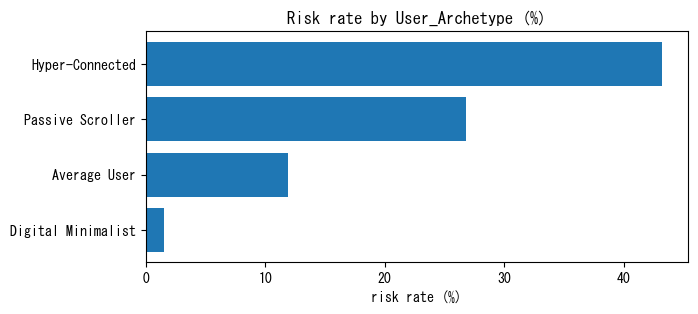

In [18]:
plt.figure(figsize=(7,3))
vals = (archetype_rate * 100).sort_values(ascending=True)
plt.barh(vals.index, vals.values)
plt.title("Risk rate by User_Archetype (%)")
plt.xlabel("risk rate (%)")
plt.show()

**EN**

Archetypes exhibit substantial differences in risk rate:

- Hyper-Connected: 43.2%
- Passive Scroller: 26.8%
- Average User: 11.9%
- Digital Minimalist: 1.5%

The nearly 30× gap between Hyper-Connected and Digital Minimalist indicates strong behavioral stratification.

This supports segmentation-aware modeling and risk analysis.


**JP**

アーキタイプ間には顕著なリスク差が確認される：

- Hyper-Connected：43.2%
- Passive Scroller：26.8%
- Average User：11.9%
- Digital Minimalist：1.5%

Hyper-Connected と Digital Minimalist の間には約30倍の差が存在し、行動特性による強い層別化が示される。

セグメントを考慮した分析・モデル化の妥当性が支持される。

## 6. Weak / Non-informative Signals / 効果が弱い（差が小さい）シグナル

**EN**

We examine variables that display limited separation across target groups.

Identifying weak signals helps prevent over-attributionand reduces unnecessary feature complexity.


**JP**

クラス間の分離が限定的な変数も確認する。

弱いシグナルを明示することで、過剰解釈を避け、不要な特徴量の複雑化を防ぐ。

In [19]:
(df.groupby("Gender")["target"].mean() * 100).round(1)

Gender
Female    21.4
Male      20.5
Name: target, dtype: float64

In [20]:
(df.groupby("Primary_Platform")["target"].mean() * 100).round(1).sort_values(ascending=False)

Primary_Platform
Instagram    22.6
Snapchat     21.1
Facebook     21.0
TikTok       20.8
Twitter/X    20.7
LinkedIn     20.5
YouTube      19.8
Name: target, dtype: float64

**EN**

Gender shows minimal separation (21.4% vs 20.5%, <1pp difference).

Platform choice varies within a narrow band (19.8%–22.6%), indicating weak standalone discriminatory power.

While these variables may contribute in multivariate models, they are unlikely to act as dominant predictors individually.


**JP**

性別による差は非常に小さい（21.4% vs 20.5%、差は1ポイント未満）。

プラットフォーム別のリスク率も19.8%～22.6%の範囲に収まり、単独では分離力が限定的である。

多変量モデルでは補助的に寄与する可能性はあるが、単体で主要因となる可能性は低い。


## 7. EDA Summary / EDAまとめ

**EN**

Key findings:

- Behavioral variables demonstrate clear distribution differences between target groups.
- Late-night usage (3.9% vs 48.7%) and sleep duration (~1 hour gap) show the strongest separation.
- Daily screen time exhibits a large behavioral gap (~2.5 hours difference).
- Archetypes reveal strong stratification (1.5%–43.2% risk range).
- Gender and platform choice show limited standalone separation.

These results justify proceeding with baseline modeling.

Next notebook: `02_baselines.ipynb`
(Dummy classifier + heuristic rule + metric comparison).


**JP**

主な結果：

- 行動指標にはクラス間で明確な分布差が確認された。
- 深夜利用（3.9% vs 48.7%）と睡眠時間（約1時間差）が特に強い分離を示す。
- スクリーンタイムにも約2.5時間の大きな差が見られる。
- アーキタイプでは1.5%～43.2%の広いリスク幅が確認された。
- 性別およびプラットフォーム単体の分離力は限定的である。

以上の結果を踏まえ、ベースラインモデルの構築に進む。

次：`02_baselines.ipynb`
（Dummy分類器 + ルールベース + 指標比較）